### Feature Bypass

Note on use of AI: I used a dialog with ChatGPT-4o about how to teach about why a bypass mechanism can be useful in designing GCN-based classifiers. The writing in this tutorial is a blend of my own and input from Chat.

#### The Problem

Imagine you’re training a GNN for node classification. Each node has a feature vector that on its own is already correlated with the node’s class (e.g., keywords in a document graph or user metadata in a social network).

If we pass these features through multiple graph convolution layers, they get mixed with neighbors’ features. That’s great for capturing structure but may dilute or lose the original predictive signal from the node’s own features in some cases.

We'll use a synthetic dataset from Chat to illustrate the key ideas.

---

#### Synthetic Graph with Node Features and Labels


In [7]:
import torch
import numpy as np
import networkx as nx
from torch_geometric.utils import from_networkx
from torch_geometric.data import Data as PyGData
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

# 1. Create 3 well-separated feature clusters (linearly separable)
num_classes = 3
nodes_per_class = 40
total_nodes = num_classes * nodes_per_class
feature_dim = 8

X, y = make_classification(
    n_samples=total_nodes,
    n_features=feature_dim,
    n_informative=feature_dim,
    n_redundant=0,
    n_clusters_per_class=1,
    n_classes=num_classes,
    class_sep=2.0,
    random_state=42
)

X = StandardScaler().fit_transform(X)

# 2. Create an stochastic block model graph with 3 communities (not aligned with classes)
sizes = [nodes_per_class] * num_classes
probs = [[0.6, 0.02, 0.02],
         [0.02, 0.6, 0.02],
         [0.02, 0.02, 0.6]]

G: nx.Graph = nx.stochastic_block_model(sizes, probs, seed=42)


Assign node features 

In [8]:
# 3. Randomly assign class-based features to stochastic block model nodes
node_indices = np.arange(total_nodes)
np.random.shuffle(node_indices)

node_feature_map = dict(zip(G.nodes(), node_indices))
for i in G.nodes:
    G.nodes[i]['x'] = torch.tensor(X[node_feature_map[i]], dtype=torch.float)
    G.nodes[i]['y'] = int(y[node_feature_map[i]])

# 4. Convert to PyG data
data: PyGData = from_networkx(G)
data.x = torch.stack([data.x[i] for i in range(data.num_nodes)])
data.y = torch.tensor([G.nodes[i]['y'] for i in range(data.num_nodes)], dtype=torch.long)

# 5. Create train/val/test split
data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.val_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)

data.train_mask[:60] = True
data.val_mask[60:90] = True
data.test_mask[90:] = True

Show graph with nodes clustered by community but node colors indicating node class

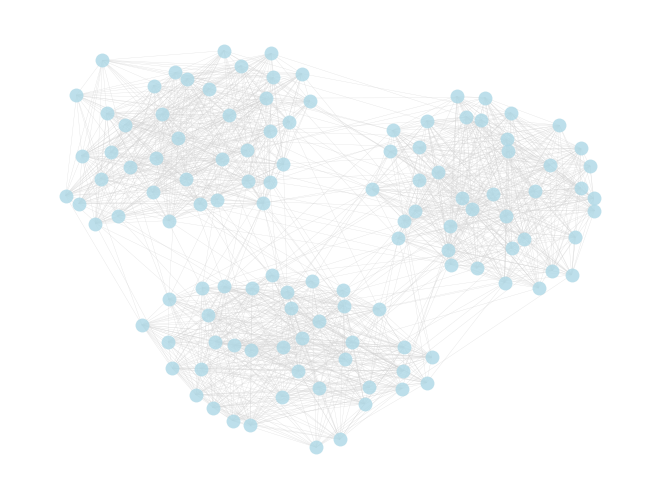

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Get node class labels
node_classes = [G.nodes[i]['y'] for i in G.nodes]

# Set up colormap
cmap = plt.get_cmap("tab10")
unique_classes = sorted(set(node_classes))
colors = [cmap(c / max(unique_classes)) for c in node_classes]

# Draw the graph 
pos = nx.nx_pydot.graphviz_layout(G, prog='neato')
nx.draw(
    G,
    pos,
    node_size=100,
    node_color='lightblue',
    edge_color='lightgray',
    width=0.2,
    alpha=0.8,
    linewidths=0.0
)


Text(0.5, 1.0, 'Nodes Colored by Class and Grouped by Community')

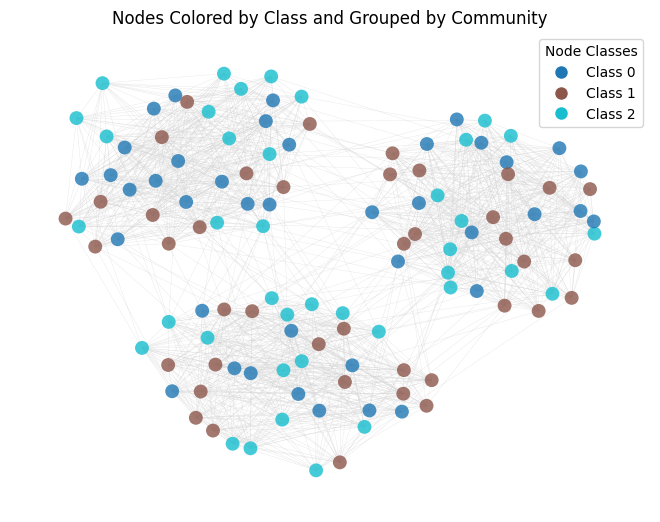

In [10]:

# Draw the graph with nodes by type
#pos = nx.nx_pydot.graphviz_layout(G, prog='neato')
nx.draw(
    G,
    pos,
    node_size=100,
    node_color=colors,
    edge_color='lightgray',
    width=0.2,
    alpha=0.8,
    linewidths=0.0
)

# Create custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'Class {cls}',
           markerfacecolor=cmap(cls / max(unique_classes)), markersize=10)
    for cls in unique_classes
]

plt.legend(handles=legend_elements, title="Node Classes", loc="best")
plt.title("Nodes Colored by Class and Grouped by Community")


Show graph with nodes clustered by type

Text(0.5, 1.0, 't-SNE Layout: Nodes Clustered by Feature Class')

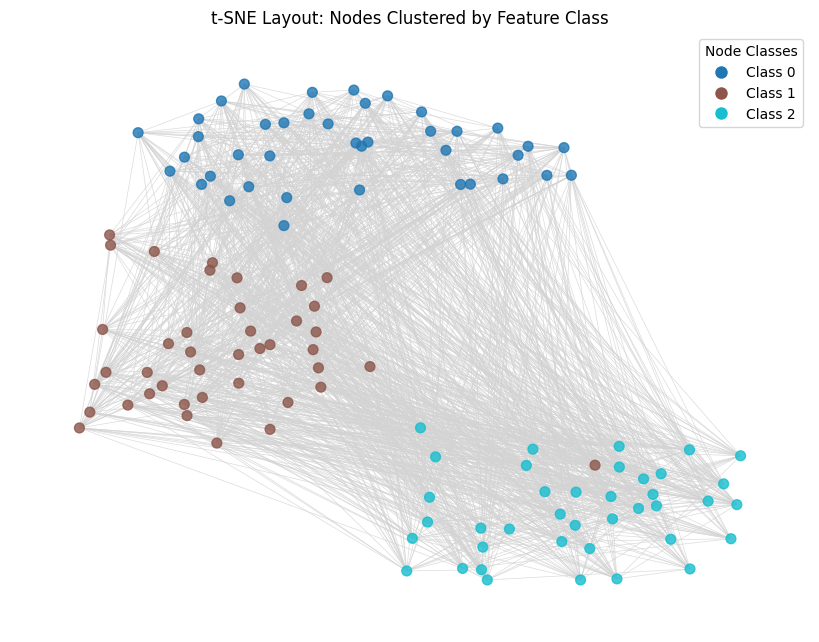

In [11]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# 1. Compute 2D t-SNE layout from node features
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(data.x)

# 2. Create position dictionary for networkx
tsne_pos = {i: (X_tsne[i, 0], X_tsne[i, 1]) for i in range(data.num_nodes)}

# 3. Get node colors by class
node_colors = [G.nodes[i]['y'] for i in G.nodes]

# 4. Draw the graph
plt.figure(figsize=(8, 6))
nx.draw(
    G,
    pos=tsne_pos,
    node_color=node_colors,
    cmap='tab10',
    edge_color='lightgray',
    node_size=50,
    width=0.5,
    alpha=0.8
)
plt.legend(handles=legend_elements, title="Node Classes", loc="best")
plt.title("t-SNE Layout: Nodes Clustered by Feature Class")

**Linear Classifier**

Let's look at what can be gained from using only node features to classify results. We'll do this by creating a linear classifier. We'll use the same structures we've used before in our GNNs, but the result will only have a single linear layer.

<img src="figures/linear_classifier_diagram.png" alt="Linear classifier" width = "400">

In [12]:
############
## Cell 1 ##
############

import torch.nn as nn
import torch.nn.functional as F

class LinearClassifier(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim)

    def forward(self, x):
        return self.fc(x)

model: nn.Module = LinearClassifier(data.num_node_features, num_classes)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


We'll train the model and test it on the embedding. Note that the classifier does not include information about the graph structures, just the node features. We expect the performance to be very good since we set up the node features to work well with a linear classifier. 

In [13]:
############
## Cell 2 ##
############

def train(model: nn.Module):
    model.train()  # Puts the model in training mode
    optimizer.zero_grad()
    out: torch.Tensor = model(data.x)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test(model: nn.Module):
    model.eval() # Puts the model in evaluation mode
    out: torch.Tensor = model(data.x)
    pred = out.argmax(dim=1)
    accs = []
    for mask in [data.train_mask, data.val_mask, data.test_mask]:
        correct = pred[mask] == data.y[mask]
        accs.append(int(correct.sum()) / int(mask.sum()))
    return accs


In [14]:
############
## Cell 3 ##
############

# Train
for epoch in range(100):
    loss = train(model)
    if epoch % 10 == 0:
        train_acc, val_acc, test_acc = test(model)
        print(f"Epoch {epoch}, Train: {train_acc:.2f}, Val: {val_acc:.2f}, Test: {test_acc:.2f}")

Epoch 0, Train: 0.52, Val: 0.67, Test: 0.63
Epoch 10, Train: 0.82, Val: 0.80, Test: 0.87
Epoch 20, Train: 0.92, Val: 0.90, Test: 0.90
Epoch 30, Train: 0.92, Val: 0.90, Test: 0.93
Epoch 40, Train: 0.93, Val: 0.93, Test: 0.93
Epoch 50, Train: 0.95, Val: 0.93, Test: 0.93
Epoch 60, Train: 0.97, Val: 0.93, Test: 0.93
Epoch 70, Train: 0.98, Val: 0.93, Test: 0.97
Epoch 80, Train: 0.98, Val: 0.93, Test: 0.97
Epoch 90, Train: 0.98, Val: 0.93, Test: 0.97


The classifier performs very well, confirming that we designed the node features well.

---

**GCN Performance**

The GCN based classifiers use both the node features and the graph structure. At each layer, a node convolves its neighbors features with its own go get a kind of blended representation of the local graph. Since the graph we constructed is designed to have a strong structural similarity properties, we might expect the convolution with local graph structures to overwhelm the information in the feature vector. 

Let's look at how a 2-layer GCN will work on the same dataset when used to semi-supervised learning. 

<img src="figures/graph_neural_network_classifier.png" alt="GCN Classifier with two GCN layers" width = "600">

In [15]:

############
## Cell 4 ##
############

from torch_geometric.nn import GCNConv

class TwoLayerGCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim*2)
        self.conv2 = GCNConv(hidden_dim*2, hidden_dim)
        self.output = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = self.output(x)
        return x

gcn_model: nn.Module = TwoLayerGCN(data.num_node_features, 16, num_classes)
optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.01)


In [16]:
############
## Cell 5 ##
############

def train_gcn(model: nn.Module):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()



In [17]:
############
## Cell 6 ##
############

# Train GCN
for epoch in range(100):
    loss = train_gcn(gcn_model)
    if epoch % 10 == 0:
        gcn_model.eval()
        out: torch.Tensor = gcn_model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        accs = []
        for mask in [data.train_mask, data.val_mask, data.test_mask]:
            correct = pred[mask] == data.y[mask]
            accs.append(int(correct.sum()) / int(mask.sum()))
        print(f"[GCN] Epoch {epoch}, Train: {accs[0]:.2f}, Val: {accs[1]:.2f}, Test: {accs[2]:.2f}")

[GCN] Epoch 0, Train: 0.25, Val: 0.43, Test: 0.40
[GCN] Epoch 10, Train: 0.42, Val: 0.20, Test: 0.33
[GCN] Epoch 20, Train: 0.42, Val: 0.20, Test: 0.33
[GCN] Epoch 30, Train: 0.57, Val: 0.23, Test: 0.33
[GCN] Epoch 40, Train: 0.63, Val: 0.57, Test: 0.47
[GCN] Epoch 50, Train: 0.72, Val: 0.60, Test: 0.33
[GCN] Epoch 60, Train: 0.75, Val: 0.63, Test: 0.47
[GCN] Epoch 70, Train: 0.73, Val: 0.60, Test: 0.57
[GCN] Epoch 80, Train: 0.80, Val: 0.63, Test: 0.57
[GCN] Epoch 90, Train: 0.78, Val: 0.60, Test: 0.57


The local node features are available to the classifier, but the two convolution layers emphasize local graph structures at the expense of these strong node features. Consequently, the classifier does not perform very well on the non-training sets.

---

### Bypass Model

#### What is a Bypass Mechanism?

A **bypass mechanism** (also called a **skip connection**, **residual connection**, or **direct path**) allows raw node features to **skip past** the graph convolution layers and directly contribute to the final prediction. Instead of relying solely on neighborhood-aggregated embeddings, the model is given access to both:

- **GCN-transformed features**, which reflect local graph structure, and
- **Original input features**, which may contain strong class-specific signals.

---

#### Why is This Useful?

In some graphs, especially synthetic or real-world datasets where node features are already highly predictive, GCN layers may dilute the signal. This happens because GCNs mix information from neighboring nodes — great for smoothing, but harmful if neighbors belong to different classes.

By combining both signals — structural and intrinsic — we let the model **decide** how much weight to assign each.

This approach is especially useful when:

- Graph structure does not align with class boundaries.
- Node features are strong but sparse.
- Some nodes are poorly connected (e.g., low-degree nodes).

---

#### How Is It Implemented?

In PyTorch or PyTorch Geometric, we typically combine the original feature matrix `x` with the output of GCN layers `h` using `torch.cat`, like this:

```python
x_orig = x  # input features
h = GCN(x, edge_index)  # structure-aware features
combined = torch.cat([h, x_orig], dim=1)  # stack along feature dimension



Essentially, this stacks the embedding `h` and the original feature tensor `x_orig` on top of each other so that the linear layer uses both in predicting the output class

#### Implementing a Bypass Model

The classifier in the code below has two hidden layers, but only one of the hidden layers is shown in the figure below for simplicity.

<img src="figures/GCN_classifier_with_bypass.png" alt="GCN Classifier with bypass" width = "600">

Observe how the graph structure and feature vectors are passed to the GCN layers as before, but the feature vectors are also passed around the GCN layers to be stacked with the embedding. 

In [18]:
############
## Cell 7 ##
############

class GCNWithBypass(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim + in_dim, out_dim)

    def forward(self, x, edge_index) -> torch.Tensor:
        x_orig = x  # save input features
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = torch.cat([x, x_orig], dim=1)
        return self.classifier(x)

bypass_model: nn.Module = GCNWithBypass(data.num_node_features, 16, num_classes)
optimizer = torch.optim.Adam(bypass_model.parameters(), lr=0.01)


In [19]:
############
## Cell 8 ##
############

def train_bypass(model: nn.Module):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


In [20]:
############
## Cell 9 ##
############

# Train bypass model
for epoch in range(100):
    loss = train_bypass(bypass_model)
    if epoch % 10 == 0:
        bypass_model.eval()
        out = bypass_model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        accs = []
        for mask in [data.train_mask, data.val_mask, data.test_mask]:
            correct = pred[mask] == data.y[mask]
            accs.append(int(correct.sum()) / int(mask.sum()))
        print(f"[Bypass] Epoch {epoch}, Train: {accs[0]:.2f}, Val: {accs[1]:.2f}, Test: {accs[2]:.2f}")

[Bypass] Epoch 0, Train: 0.28, Val: 0.37, Test: 0.20
[Bypass] Epoch 10, Train: 0.77, Val: 0.70, Test: 0.63
[Bypass] Epoch 20, Train: 0.92, Val: 0.90, Test: 0.93
[Bypass] Epoch 30, Train: 0.93, Val: 0.97, Test: 0.90
[Bypass] Epoch 40, Train: 0.93, Val: 0.97, Test: 0.93
[Bypass] Epoch 50, Train: 0.95, Val: 0.97, Test: 0.93
[Bypass] Epoch 60, Train: 0.95, Val: 0.97, Test: 0.97
[Bypass] Epoch 70, Train: 0.97, Val: 0.97, Test: 0.90
[Bypass] Epoch 80, Train: 0.98, Val: 0.90, Test: 0.80
[Bypass] Epoch 90, Train: 0.98, Val: 0.87, Test: 0.63


The classifier accuracy with the bypass mechanism is higher than for the classifier without bypass mechanism. However, the performance is not as high as the linear classifier. Why? 

The key take away from this tutorial is a reminder. GNNs use the following correlations together to classify nodes:
- correlations between node features
- correlations between node structural similarities
- correlations between aggregated features and structures

Consequently, we'd expect the behavior of the classifier to include information from both the graph structure and the node features. And this leads to a balance between what is emphasized: node features or graph structure.

The bypass mechanism delegates the responsibility for finding this balance to the output linear layer. It says "Here is what I've aggregated from node features and graph structures, and here are the node features. Use classifier error to find the balance between them."

The validation and test accuracy jumps around a lot while the training accuracy goes up. Let's add some dropout to minimize overfitting.

In [21]:
#############
## Cell 10 ##
#############

import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCNWithBypassReg(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)

        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        # Project bypass so classifier does not rely too heavily on raw features
        self.skip_proj = nn.Linear(in_dim, hidden_dim // 2)

        self.dropout = dropout
        self.classifier = nn.Linear(hidden_dim + hidden_dim // 2, out_dim)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = self.bn1(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        h = self.conv2(h, edge_index)
        h = self.bn2(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        s = F.relu(self.skip_proj(x))
        s = F.dropout(s, p=self.dropout, training=self.training)

        z = torch.cat([h, s], dim=1)
        return self.classifier(z)

In [ ]:
#############
## Cell 11 ##
#############

bypass_model = GCNWithBypassReg(data.num_node_features, hidden_dim=8, out_dim=num_classes, dropout=0.5)
optimizer = torch.optim.AdamW(bypass_model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

def compute_acc(logits: torch.Tensor, labels: torch.Tensor, mask: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    correct = (preds[mask] == labels[mask]).sum().item()
    total = int(mask.sum().item())
    return correct / total if total > 0 else 0.0

# Train bypass model with early stopping
best_state = None
best_val_loss = float("inf")
patience = 20
wait = 0

for epoch in range(300):
    bypass_model.train()
    optimizer.zero_grad()
    out = bypass_model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    bypass_model.eval()
    with torch.no_grad():
        out = bypass_model(data.x, data.edge_index)
        train_acc = compute_acc(out, data.y, data.train_mask)
        val_acc = compute_acc(out, data.y, data.val_mask)
        test_acc = compute_acc(out, data.y, data.test_mask)
        val_loss = criterion(out[data.val_mask], data.y[data.val_mask]).item()

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | Loss {loss.item():.2f} | "
            f"Train {train_acc:.2f} | Val {val_acc:.2f} | Test {test_acc:.2f}"
        )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(bypass_model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# Restore best model and print final metrics
if best_state is not None:
    bypass_model.load_state_dict(best_state)

bypass_model.eval()
with torch.no_grad():
    out = bypass_model(data.x, data.edge_index)
    train_acc = compute_acc(out, data.y, data.train_mask)
    val_acc = compute_acc(out, data.y, data.val_mask)
    test_acc = compute_acc(out, data.y, data.test_mask)

print(
    f"Best-checkpoint accuracy | Train {train_acc:.2f} | "
    f"Val {val_acc:.2f} | Test {test_acc:.2f}"
)

Epoch 000 | Loss 1.2049 | Train 0.367 | Val 0.467 | Test 0.333
Epoch 010 | Loss 1.0648 | Train 0.600 | Val 0.633 | Test 0.400
Epoch 020 | Loss 0.9586 | Train 0.767 | Val 0.700 | Test 0.533
Epoch 030 | Loss 0.8187 | Train 0.883 | Val 0.800 | Test 0.467
Epoch 040 | Loss 0.6945 | Train 0.900 | Val 0.867 | Test 0.467
Epoch 050 | Loss 0.6220 | Train 0.950 | Val 0.900 | Test 0.733
Epoch 060 | Loss 0.6406 | Train 0.967 | Val 0.900 | Test 0.833
Epoch 070 | Loss 0.6454 | Train 0.967 | Val 0.900 | Test 0.833
Epoch 080 | Loss 0.6235 | Train 0.967 | Val 0.867 | Test 0.833
Epoch 090 | Loss 0.7146 | Train 0.967 | Val 0.900 | Test 0.833
Epoch 100 | Loss 0.5381 | Train 0.967 | Val 0.933 | Test 0.900
Epoch 110 | Loss 0.6790 | Train 0.983 | Val 0.967 | Test 0.900
Epoch 120 | Loss 0.6421 | Train 0.983 | Val 1.000 | Test 0.900
Epoch 130 | Loss 0.5702 | Train 0.983 | Val 0.967 | Test 0.900
Epoch 140 | Loss 0.4991 | Train 0.983 | Val 0.967 | Test 0.900
Epoch 150 | Loss 0.6019 | Train 0.983 | Val 0.967 | Tes